# How to use the dataset: shuffled dataset
In this notebook, we show examples of usage for the dataset
- We use Isolation Forest with a shuffled dataset to perform a classification of normal/attack instances.
- We perform the same classification using XGBoost.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Import the dataset

In [ ]:
import pandas as pd
import numpy as np
from ast import literal_eval

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/專題/Zero-Trust-Authentication-Based-on-ROS2/rospace_dataset/noperiodicity_final_0531.csv")

In [ ]:
print(df.columns)
print(df.shape)

Index(['msg_data', 'pgpgin', 'layers.dns.dns.flags', 'layers.udp.udp.payload',
       'layers.dns.dns.flags_tree.dns.flags.truncated', 'pgmajfault',
       'Tcp_Syn', 'nr_inactive_file', 'pgalloc_dma', 'topic_name',
       'layers.dns.dns.count.add_rr',
       'layers.dns.dns.flags_tree.dns.flags.recavail',
       'layers.rtps.rtps.vendorId', 'layers.dns.dns.response_to', 'pgactivate',
       'layers.icmp.udp.udp.payload',
       'layers.dns.dns.flags_tree.dns.flags.checkdisable', 'Buffers',
       'Net_Received', 'Tcp_Close', 'Disk_Write', 'MemFree', 'pgfree',
       'pgdeactivate', 'Net_Sent', 'msg_type', 'layers.ip.ip.ttl',
       'layers.rtps.rtps.version',
       'layers.dns.dns.flags_tree.dns.flags.recdesired',
       'layers.udp.udp.stream.pnum', 'publisher_count', 'pgpgout',
       'layers.rtps.rtps.version_tree.rtps.version.major',
       'layers.dns.dns.flags_tree.dns.flags.z', 'Tcp_Established',
       'layers.ip.ip.stream',
       'layers.rtps.rtps.version_tree.rtps.version

In [ ]:
nanv = []
for col in df.columns:
    nanv.append(df[col].isnull().values.any())

In [ ]:
print(nanv)

[np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_]


In [ ]:
df.replace([np.inf, -np.inf], -1, inplace=True)
df.fillna(-1, inplace=True)
df=df.dropna(thresh=1, axis=1)

In [ ]:
df.replace('nan', -1, inplace=True)

In [ ]:
nanv = []
for col in df.columns:
    nanv.append(df[col].isnull().values.any())
print(nanv)

[np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_]


In [ ]:
print(df['attack'].value_counts())

attack
0    50335
1     9135
Name: count, dtype: int64


In [ ]:
# 確保資料是按照時間戳順序排列 (時序防禦的核心)
if 'timestamp' in df.columns:
    df = df.sort_values(by='timestamp').reset_index(drop=True)
else:
    # 如果原 58 特徵不含實體 timestamp，則假設 index 順序即為時序，給予虛擬時間戳(如每列間隔0.01秒)
    df['timestamp'] = df.index * 0.01

print(f"原始資料維度: {df.shape}") # 應為 (樣本數, 58 或 59 含timestamp)

# 2. 🔍 邏輯擴增特徵一：計算 1 秒內的封包總數 (recent_packets_in_1s)
# 使用 pandas 的 rolling 功能，以 1 秒為視窗計算個數
# 必須先把 timestamp 轉成 datetime 格式才能做時間窗 rolling
df['dt'] = pd.to_datetime(df['timestamp'], unit='s')
df = df.set_index('dt')

# 計算過去 1 秒內的資料筆數 (代表高頻網路的封包密度)
df['recent_packets_in_1s'] = df['timestamp'].rolling('1s').count()

原始資料維度: (59470, 63)


In [ ]:
if 'Tcp_Syn' in df.columns:
    # 如果 OS monitor 欄位有值，或網路層有標記
    df['is_syn'] = df['Tcp_Syn'].apply(lambda x: 1 if x > 0 else 0)
elif 'layers.tcp.tcp.flags' in df.columns:
    df['is_syn'] = df['layers.tcp.tcp.flags'].apply(lambda x: 1 if x == '0x0002' or x == 2 else 0)
else:
    # 備用防禦邏輯：若無明確 flags，以網路協定為 TCP 且具有特定特徵者替代
    df['is_syn'] = 0

# 利用 rolling 計算 1 秒內 SYN 的總數，並除以總封包數得到比例
syn_count_1s = df['is_syn'].rolling('1s').sum()
df['recent_syn_ratio_in_1s'] = syn_count_1s / df['recent_packets_in_1s']
df['recent_syn_ratio_in_1s'] = df['recent_syn_ratio_in_1s'].fillna(0) # 處理除以0的狀況

# 清理臨時欄位，並恢復索引
df = df.reset_index(drop=True)
df.drop(columns=['is_syn'], inplace=True, errors='ignore')

In [ ]:
print(df.columns)

Index(['msg_data', 'pgpgin', 'layers.dns.dns.flags', 'layers.udp.udp.payload',
       'layers.dns.dns.flags_tree.dns.flags.truncated', 'pgmajfault',
       'Tcp_Syn', 'nr_inactive_file', 'pgalloc_dma', 'topic_name',
       'layers.dns.dns.count.add_rr',
       'layers.dns.dns.flags_tree.dns.flags.recavail',
       'layers.rtps.rtps.vendorId', 'layers.dns.dns.response_to', 'pgactivate',
       'layers.icmp.udp.udp.payload',
       'layers.dns.dns.flags_tree.dns.flags.checkdisable', 'Buffers',
       'Net_Received', 'Tcp_Close', 'Disk_Write', 'MemFree', 'pgfree',
       'pgdeactivate', 'Net_Sent', 'msg_type', 'layers.ip.ip.ttl',
       'layers.rtps.rtps.version',
       'layers.dns.dns.flags_tree.dns.flags.recdesired',
       'layers.udp.udp.stream.pnum', 'publisher_count', 'pgpgout',
       'layers.rtps.rtps.version_tree.rtps.version.major',
       'layers.dns.dns.flags_tree.dns.flags.z', 'Tcp_Established',
       'layers.ip.ip.stream',
       'layers.rtps.rtps.version_tree.rtps.version

In [ ]:
list_column_string=df.select_dtypes(exclude=[np.number])

for i in list_column_string:
    if i != 'timestamp':
        df[i] = pd.Categorical(df[i])

In [ ]:
for i in list_column_string:
    if i != 'timestamp':
        df[i] = df[i].cat.codes

In [ ]:
blacklist_features = [
    'timestamp',                    # ❌ 時間戳 (致命誤判源)
    'layers.frame.frame.time',      # ❌ 包含絕對時間字串的欄位
    'layers.ip.ip.checksum',        # ❌ IP 隨機校驗碼
    'layers.udp.udp.checksum',       # ❌ UDP 隨機校驗碼
    'layers.udp.udp.stream.pnum'    # ❌ UDP 隨機流序號
]

df = df.drop(columns=blacklist_features, errors='ignore')

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
subs = "Unnamed"
res = [i for i in df.columns if subs in i]
print(len(res))
print(res)
df=df.drop(res, axis=1)

0
[]


In [ ]:
label = df['attack']
df = df.drop(['attack'], axis=1)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(df, label, test_size=0.4, random_state=42)

# --- [新增] 將特徵資料強制轉為 float32 以節省顯示記憶體 ---
X_train = x_train.astype('float32')
X_test = x_test.astype('float32')

x_train = x_train.to_numpy()
x_test = x_test.to_numpy()

In [ ]:
print("Train Set Shape: " + str(x_train.shape))
print("Train Set Label Shape: " + str(y_train.shape))
print("Test Set Shape: " + str(x_test.shape))
print("Test Set Label Shape: " + str(y_test.shape))

Train Set Shape: (35682, 62)
Train Set Label Shape: (35682,)
Test Set Shape: (23788, 62)
Test Set Label Shape: (23788,)


## Binary classification with XGBoost

In [ ]:
%pip install xgboost
from xgboost import XGBClassifier
import sklearn

In [ ]:
blacklist_features = [
    'timestamp',                    # 隨時間遞增，會導致實時推論嚴重過擬合
    'layers.ip.ip.checksum',        # 實時通訊的隨機校驗碼亂數
    'layers.udp.udp.stream.pnum'    # UDP 封包隨機累加序號
]
df = df.drop(columns=['attack'] + blacklist_features, errors='ignore')

In [ ]:
print(df.columns)

Index(['msg_data', 'pgpgin', 'layers.dns.dns.flags', 'layers.udp.udp.payload',
       'layers.dns.dns.flags_tree.dns.flags.truncated', 'pgmajfault',
       'Tcp_Syn', 'nr_inactive_file', 'pgalloc_dma', 'topic_name',
       'layers.dns.dns.count.add_rr',
       'layers.dns.dns.flags_tree.dns.flags.recavail',
       'layers.rtps.rtps.vendorId', 'layers.dns.dns.response_to', 'pgactivate',
       'layers.icmp.udp.udp.payload',
       'layers.dns.dns.flags_tree.dns.flags.checkdisable', 'Buffers',
       'Net_Received', 'Tcp_Close', 'Disk_Write', 'MemFree', 'pgfree',
       'pgdeactivate', 'Net_Sent', 'msg_type', 'layers.ip.ip.ttl',
       'layers.rtps.rtps.version',
       'layers.dns.dns.flags_tree.dns.flags.recdesired', 'publisher_count',
       'pgpgout', 'layers.rtps.rtps.version_tree.rtps.version.major',
       'layers.dns.dns.flags_tree.dns.flags.z', 'Tcp_Established',
       'layers.ip.ip.stream',
       'layers.rtps.rtps.version_tree.rtps.version.minor',
       'layers.dns.dns.flags

In [ ]:
# 🟢 正確修正：不要用 np.arange()，改為直接抓取 DataFrame 的真實文字欄位名稱
# 假設你的真實特徵 DataFrame 叫 x_train，或者從 df 扣除 attack

# 作法 A：如果你的 x_train 還保留著欄位名稱 (DataFrame 型態)
feature_names = x_train.columns.get_level_values(0).astype(str).tolist() if hasattr(x_train, 'columns') else df.drop(columns=['attack'], errors='ignore').columns.tolist()

# 確保移除可能包含的 attack 標籤
if 'attack' in feature_names:
    feature_names.remove('attack')

print("📊 [檢查] 真實特徵數量:", len(feature_names))
print("📜 [檢查] 前 5 個特徵名字:", feature_names[:5])
print("📜 [檢查] 最後一個特徵名字:", feature_names[-1]) # 預期會是 timestamp

# 儲存帶有「真實文字名字」的黃金模具
np.save("feature_names.npy", np.array(feature_names, dtype=object))
print("🟢 正確文字特徵模具已成功儲存！")

📊 [檢查] 真實特徵數量: 62
📜 [檢查] 前 5 個特徵名字: ['msg_data', 'pgpgin', 'layers.dns.dns.flags', 'layers.udp.udp.payload', 'layers.dns.dns.flags_tree.dns.flags.truncated']
📜 [檢查] 最後一個特徵名字: recent_syn_ratio_in_1s
🟢 正確文字特徵模具已成功儲存！


In [ ]:
important_features = {
    'layers.udp.udp.payload': 15.0,  # 網路載荷，最核心
    'msg_type': 12.0,                # ROS2 訊息類型
    'src_topic': 10.0,               # ROS2 話題來源
    'layers.udp.udp.stream': 10.0,   # UDP 串流追蹤
    'subscribers_count': 8.0,        # ROS2 節點訂閱數拓撲
    'publisher_count': 8.0           # ROS2 節點發布數拓撲
}

# 4. 定義你需要「刻意壓低」的週期性系統雜訊特徵 (設為極低權重，如 0.05)
noise_features = {
    'Inactive': 0.05,
    'MemFree': 0.05,
    'nr_active_file': 0.05,
    'nr_inactive_file': 0.05,
    'pgfault': 0.1,
    'pgactivate': 0.1,
    'pgfree': 0.1
}

weights = np.ones(len(feature_names))

for feat, weight_val in important_features.items():
    if feat in feature_names:
        idx = feature_names.index(feat)
        weights[idx] = weight_val
        print(f"🔥 已調高特徵 [{feat}] 的引導權重至: {weight_val}")

for feat, weight_val in noise_features.items():
    if feat in feature_names:
        idx = feature_names.index(feat)
        weights[idx] = weight_val
        print(f"⚠️ 已壓低特徵 [{feat}] 的引導權重至: {weight_val}")

🔥 已調高特徵 [layers.udp.udp.payload] 的引導權重至: 15.0
🔥 已調高特徵 [msg_type] 的引導權重至: 12.0
🔥 已調高特徵 [src_topic] 的引導權重至: 10.0
🔥 已調高特徵 [layers.udp.udp.stream] 的引導權重至: 10.0
🔥 已調高特徵 [subscribers_count] 的引導權重至: 8.0
🔥 已調高特徵 [publisher_count] 的引導權重至: 8.0
⚠️ 已壓低特徵 [Inactive] 的引導權重至: 0.05
⚠️ 已壓低特徵 [MemFree] 的引導權重至: 0.05
⚠️ 已壓低特徵 [nr_active_file] 的引導權重至: 0.05
⚠️ 已壓低特徵 [nr_inactive_file] 的引導權重至: 0.05
⚠️ 已壓低特徵 [pgfault] 的引導權重至: 0.1
⚠️ 已壓低特徵 [pgactivate] 的引導權重至: 0.1
⚠️ 已壓低特徵 [pgfree] 的引導權重至: 0.1


In [ ]:
bst = XGBClassifier(
    n_estimators=100,
    max_depth=6, #如果跳出Out of Memory，可以將此值調小，例如6
    learning_rate=0.1,
    colsample_bytree=0.5,
    objective='binary:logistic',
    tree_method='hist',    # 啟用直方圖演算法 (GPU 必備)
    device='cuda',          # 強制使用 NVIDIA GPU
    random_state=42
)
# fit model
bst.fit(x_train, y_train, feature_weights=weights)
# make predictions
xgb_preds = bst.predict_proba(x_test)

/usr/local/lib/python3.12/dist-packages/xgboost/sklearn.py:1183: UserWarning: `feature_weights` in `fit` method is deprecated for better compatibility with scikit-learn, use `feature_weights` in constructor or`set_params` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:33:51] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:33:51] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


First, we compute the Confusion Matrix and the Accuracy

In [ ]:
acc=sklearn.metrics.accuracy_score(y_test, xgb_preds[:, 1] > 0.5)
tn, fp, fn, tp = sklearn.metrics.confusion_matrix(y_test, xgb_preds[:, 1] > 0.5).ravel()

In [ ]:
print("Accuracy "+str(acc))
print("TN {}, FP {}, FN {}, TP {} ".format(tn, fp, fn, tp))

Accuracy 0.9926433495880276
TN 20055, FP 68, FN 107, TP 3558 


In [ ]:
rec=sklearn.metrics.recall_score(y_test, xgb_preds[:, 1] > 0.5)
print(rec)

0.9708049113233288


In [ ]:
prec=sklearn.metrics.precision_score(y_test, xgb_preds[:, 1] > 0.5)
print(prec)

0.9812465526751241


We calculate the ROC curve

In [ ]:
preds_proba = bst.predict_proba(x_test)

In [ ]:
from sklearn import metrics
import matplotlib.pyplot as plt

In [ ]:
fpr, tpr, _ = metrics.roc_curve(y_test,  preds_proba[:,1])

In [ ]:
fpr = np.asarray(fpr)
tpr = np.asarray(tpr)

In [ ]:
len(tpr)

1974

We investigate the performance of the XGBoost with a fix FPR of 0.05

In [ ]:
TARGET_FPR=0.05
fpr_index=np.min(np.where(fpr >= TARGET_FPR))
fpr_value=fpr[fpr_index]
tpr_value=tpr[fpr_index]
print("TPR {} , FPR {}".format(tpr_value, fpr_value))

TPR 0.9929058663028649 , FPR 0.051483377230035286


### Compute the Precision-Recall Curve

In [ ]:
precision, recall, thr = metrics.precision_recall_curve(y_test,  preds_proba[:,1])

In [ ]:
print(recall)
count = 0
for r in recall:
    if r <= 0.2:
        print(count)
        break
    count = count + 1

[1.         1.         1.         ... 0.28594816 0.15934516 0.        ]
2520


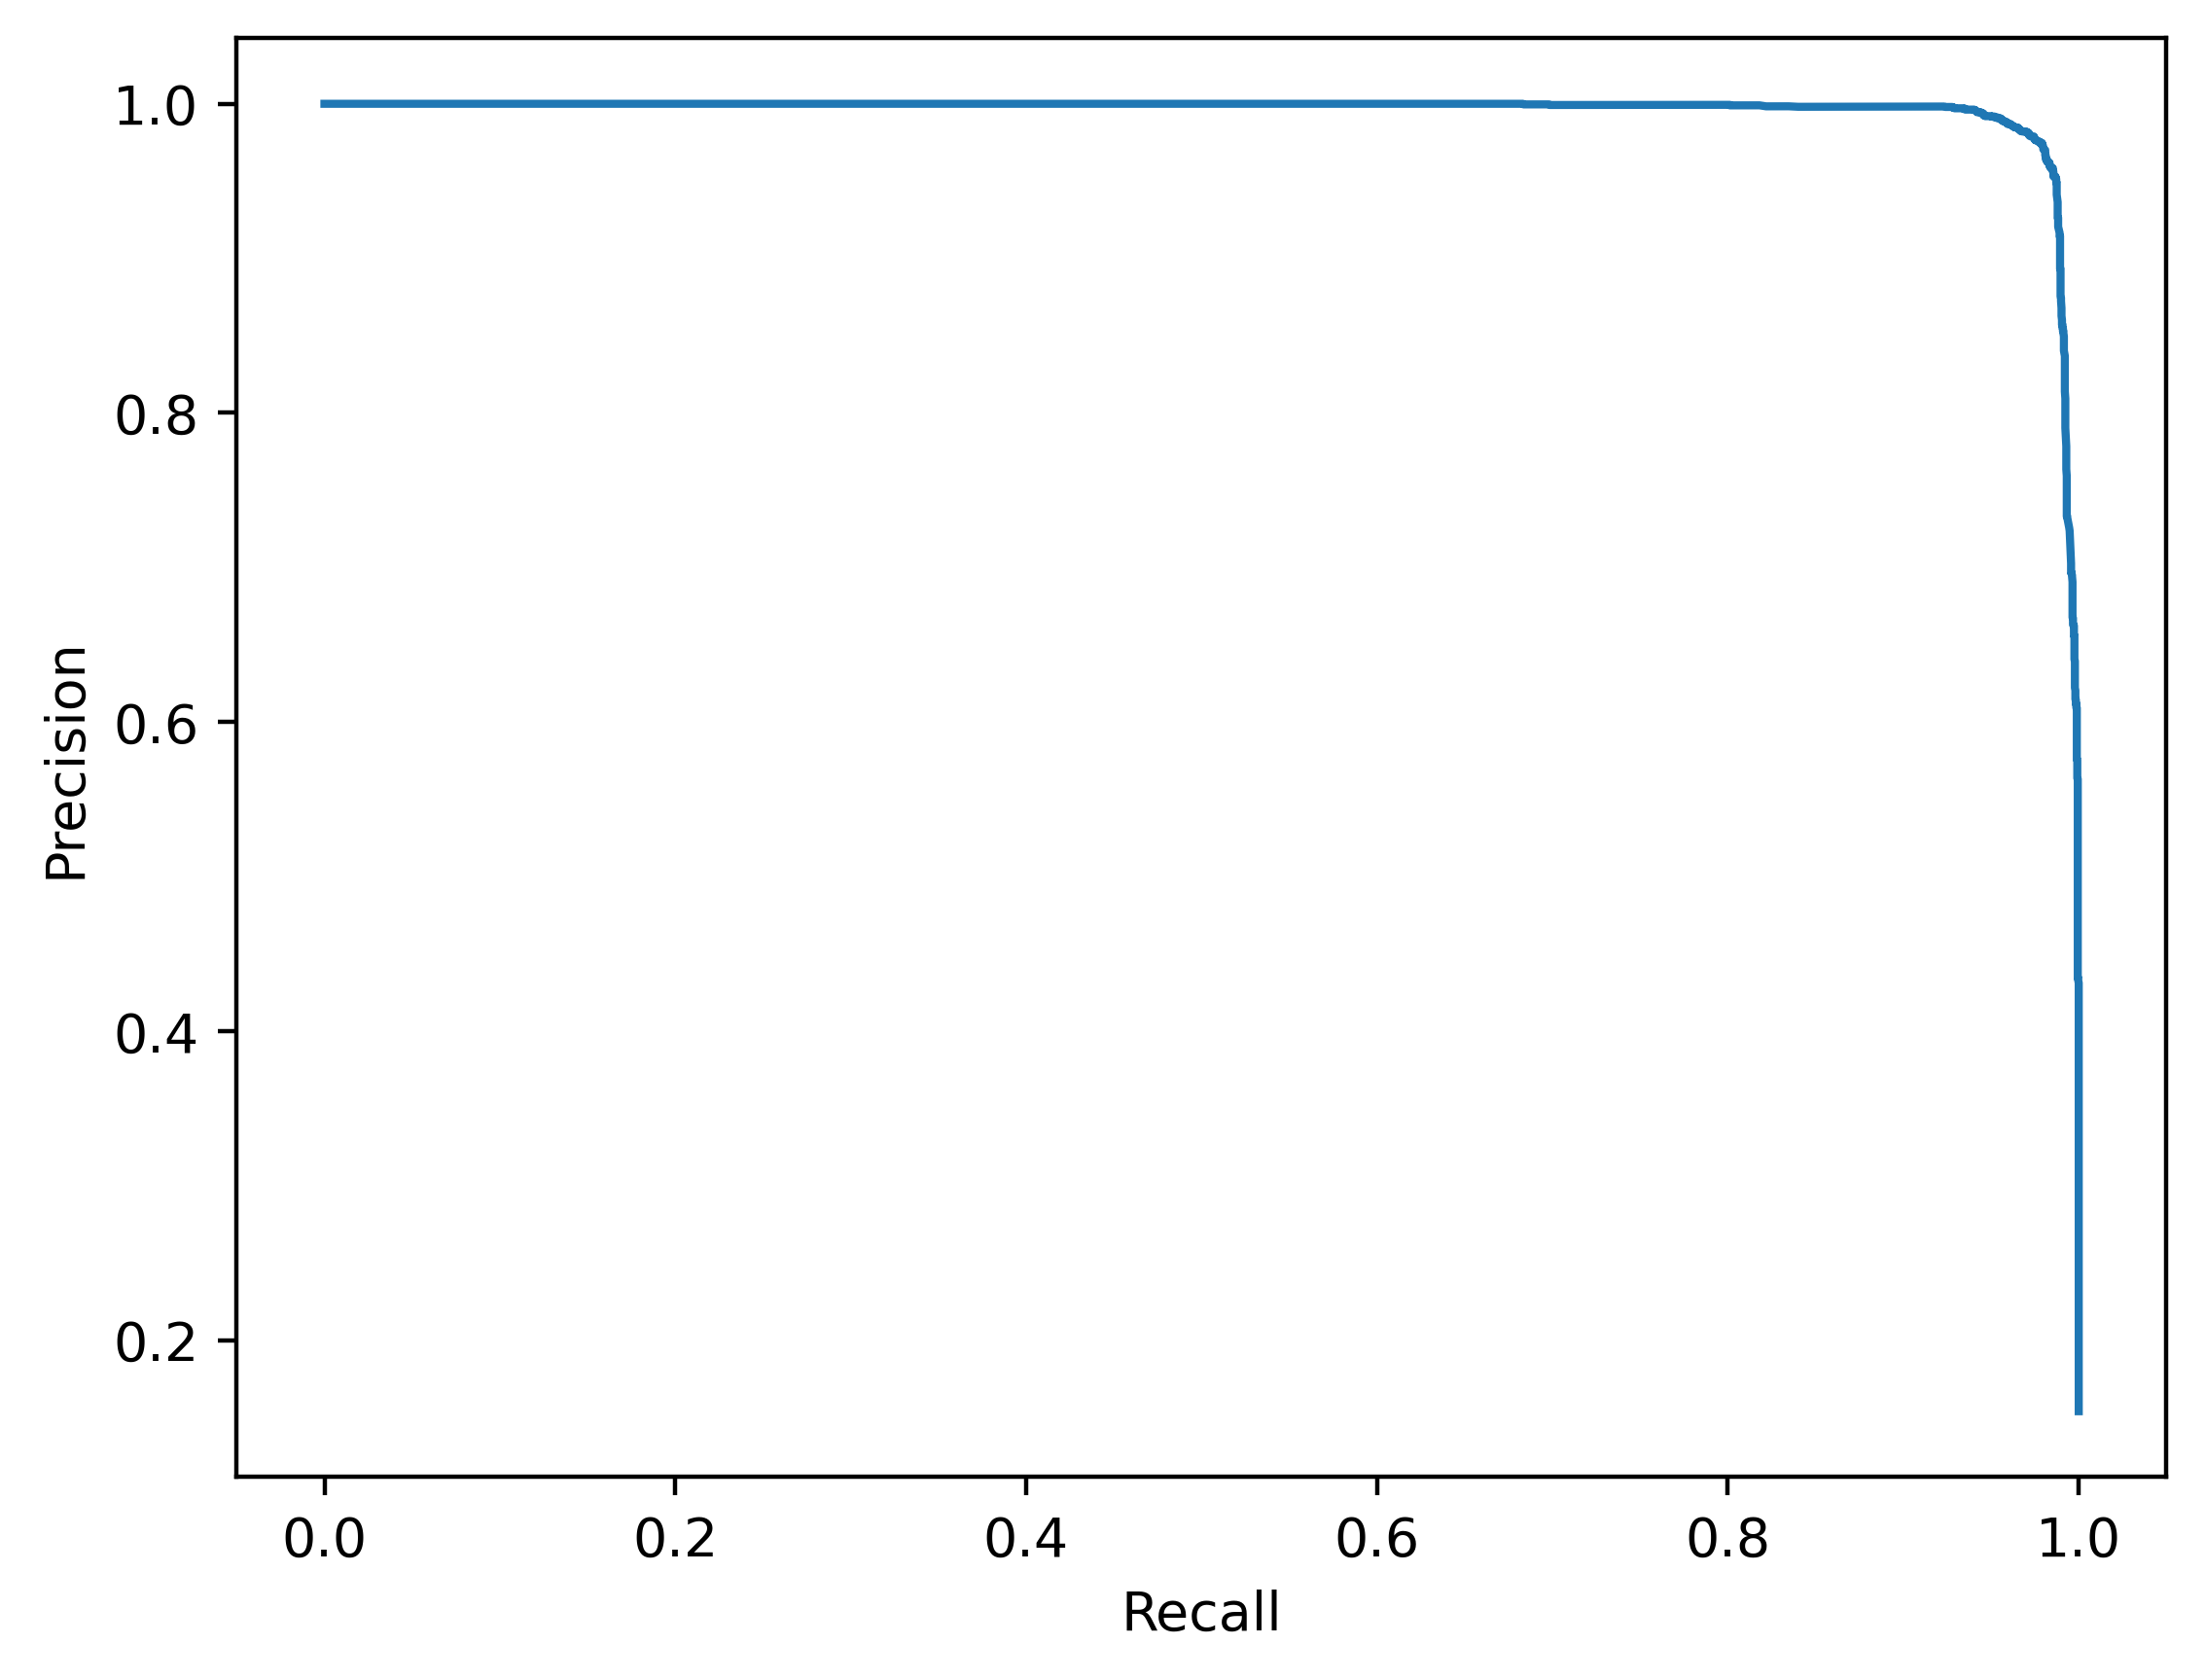

In [ ]:
plt.figure(dpi=400)
plt.plot(recall[0:512400], precision[0:512400])
plt.ylabel('Precision')
plt.xlabel('Recall')
plt.show()

In [ ]:
np.save('./recall_xgb.npy', recall)
np.save('./precision_xgb.npy', precision)

In [ ]:
import joblib
joblib.dump(bst, "xgb_model.pkl")

['xgb_model.pkl']

In [ ]:
import numpy as np
import os

NPY_PATH = "feature_names.npy"

if not os.path.exists(NPY_PATH):
    print(f"❌ 錯誤：在當前目錄下找不到 {NPY_PATH} 檔案！")
    exit(1)

# 載入 npy 檔案
try:
    loaded_features = np.load(NPY_PATH, allow_pickle=True)

    print("==================================================")
    print(f"📂 成功載入檔案: {NPY_PATH}")
    print(f"📊 資料型態 (Type): {type(loaded_features)}")
    print(f"📏 陣列維度 (Shape): {loaded_features.shape}")

    # 轉成 list 方便觀察
    feature_list = loaded_features.tolist()
    print(f"元素總數: {len(feature_list)}")
    print("==================================================\n")

    print("📜 --- 完整特徵清單與索引對照 ---")
    for idx, name in enumerate(feature_list):
        # 印出索引、內容、以及該內容的實際型態 (檢查是不是純數字或字串)
        print(f"【索引 {idx:02d}】 -> 內容: {name} (型態: {type(name).__name__})")

    print("\n==================================================")

    # 🔍 自動化核心健檢
    print("🩺 [自動健檢報告]")
    is_all_str_digits = all(str(item).isdigit() for item in feature_list)
    if is_all_str_digits:
        print("🚨 警告：這個 npy 檔案裡全部都是『數字』！這代表欄位名稱在訓練存檔時丟失了，模型只記得了數字索引。")
    else:
        print("🟢 檢查通過：檔案內包含文字特徵名稱。")

    if 'attack' in feature_list:
        print("⚠️ 提醒：清單中包含 'attack' 標籤欄位，實時推論前處理記得要剔除。")
    if 'timestamp' in feature_list:
        print(f"ℹ️ 提示：'timestamp' 位在第 {feature_list.index('timestamp')} 個索引。")

except Exception as e:
    print(f"💥 讀取 npy 檔案時發生異常: {str(e)}")

📂 成功載入檔案: feature_names.npy
📊 資料型態 (Type): <class 'numpy.ndarray'>
📏 陣列維度 (Shape): (62,)
元素總數: 62

📜 --- 完整特徵清單與索引對照 ---
【索引 00】 -> 內容: msg_data (型態: str)
【索引 01】 -> 內容: pgpgin (型態: str)
【索引 02】 -> 內容: layers.dns.dns.flags (型態: str)
【索引 03】 -> 內容: layers.udp.udp.payload (型態: str)
【索引 04】 -> 內容: layers.dns.dns.flags_tree.dns.flags.truncated (型態: str)
【索引 05】 -> 內容: pgmajfault (型態: str)
【索引 06】 -> 內容: Tcp_Syn (型態: str)
【索引 07】 -> 內容: nr_inactive_file (型態: str)
【索引 08】 -> 內容: pgalloc_dma (型態: str)
【索引 09】 -> 內容: topic_name (型態: str)
【索引 10】 -> 內容: layers.dns.dns.count.add_rr (型態: str)
【索引 11】 -> 內容: layers.dns.dns.flags_tree.dns.flags.recavail (型態: str)
【索引 12】 -> 內容: layers.rtps.rtps.vendorId (型態: str)
【索引 13】 -> 內容: layers.dns.dns.response_to (型態: str)
【索引 14】 -> 內容: pgactivate (型態: str)
【索引 15】 -> 內容: layers.icmp.udp.udp.payload (型態: str)
【索引 16】 -> 內容: layers.dns.dns.flags_tree.dns.flags.checkdisable (型態: str)
【索引 17】 -> 內容: Buffers (型態: str)
【索引 18】 -> 內容: Net_Received (型態: str)
【索引 

In [ ]:
import joblib
import numpy as np
import pandas as pd
import xgboost as xgb

# 1. 載入特徵模具
features = np.load("feature_names.npy", allow_pickle=True).tolist()
if 'attack' in features:
    features.remove('attack')

print(f"Loaded feature names framework: {len(features)} dimensions.")

# 2. 🚀 使用 joblib 載入整個模型物件
MODEL_PATH = "xgb_model.pkl"  # 你的 joblib 檔案名稱
try:
    loaded_model = joblib.load(MODEL_PATH)
    print(f"🟢 成功透過 joblib 載入模型類型: {type(loaded_model)}")
except Exception as e:
    print(f"❌ 載入 {MODEL_PATH} 失敗: {str(e)}")
    exit(1)

# 3. 提取底層的 Booster 物件或直接獲取特徵重要性
# 依據你當初訓練是用 xgb.XGBClassifier 還是 xgb.train，處理方式略有不同：
if hasattr(loaded_model, 'get_booster'):
    # 如果是用 sklearn API 封裝的 XGBClassifier/XGBRegressor
    booster = loaded_model.get_booster()
    importance_dict = booster.get_score(importance_type='weight')
elif hasattr(loaded_model, 'get_score'):
    # 如果當初 joblib 直接存的就是原生 Booster 物件
    importance_dict = loaded_model.get_score(importance_type='weight')
else:
    # 備援：嘗試使用 sklearn 介面的 feature_importances_
    print("⚠️ 未偵測到標準 Booster 介面，嘗試使用 feature_importances_ 屬性...")
    if hasattr(loaded_model, 'feature_importances_'):
        importances = loaded_model.feature_importances_
        importance_dict = {f"f{i}": val for i, val in enumerate(importances)}
    else:
        print("❌ 無法從該物件提取特徵重要性分數。")
        exit(1)

# 4. 🚀 將 XGBoost 內部的 f0, f1, f2 索引對齊回人類看得懂的欄位名稱
named_importance = {}
for k, v in importance_dict.items():
    if k.startswith('f'):
        try:
            idx = int(k[1:])
            if idx < len(features):
                named_importance[features[idx]] = v
            else:
                named_importance[f"Unknown_f{idx}"] = v
        except ValueError:
            named_importance[k] = v
    else:
        named_importance[k] = v

# 5. 轉換為 DataFrame 排序並列印前 15 名
df_imp = pd.DataFrame(list(named_importance.items()), columns=['Feature_Name', 'Importance_Score'])
df_imp = df_imp.sort_values(by='Importance_Score', ascending=False)

print("\n📊 === XGBoost (Joblib PKL) 核心權重依賴前 15 名 ===")
if not df_imp.empty:
    print(df_imp.head(15).to_string(index=False))
else:
    print("⚠️ 特徵重要性分數皆為 0，請檢查模型是否已正確擬合（Fitted）。")

Loaded feature names framework: 62 dimensions.
🟢 成功透過 joblib 載入模型類型: <class 'xgboost.sklearn.XGBClassifier'>

📊 === XGBoost (Joblib PKL) 核心權重依賴前 15 名 ===
          Feature_Name  Importance_Score
  recent_packets_in_1s             557.0
 layers.udp.udp.stream             287.0
layers.udp.udp.payload             279.0
               Buffers             234.0
          Net_Received             221.0
recent_syn_ratio_in_1s             219.0
             src_topic             158.0
                pgpgin             122.0
     subscribers_count             111.0
       publisher_count             105.0
                Active             105.0
            Disk_Write              93.0
              Net_Sent              77.0
      layers.ip.ip.ttl              71.0
            pgmajfault              48.0


In [ ]:
print(df.columns[26])

layers.ip.ip.ttl
